# Syn Bank Share-of-Wallet Intelligence Engine — Pipeline Walkthrough

Data School Hackathon 2026 · Standard Bank Corporate & Investment Banking

**Team:** Judd Jocum, Asher Hyde

This notebook walks through every stage of the pipeline and displays the
actual computed output — data ingestion, the Generative AI extraction
components, the wallet model, the Monte Carlo rigor layer, and the ranked
opportunity list.

It reads the pipeline's already-computed output (`data/processed/*.parquet`),
the same files the executive dashboard reads. It does not re-run Phase 1–3
against the raw ~430MB CSVs or call the Gemini API directly — that would
take several minutes and requires a `GEMINI_API_KEY`. For a full end-to-end
reproduction from raw data, run:

```bash
pip install -r requirements.txt
cp .env.example .env   # add your own GEMINI_API_KEY
python run_all.py
```

See `README.md` and `METHODOLOGY.md` in the repository root for the full
write-up of every assumption, design decision, and limitation.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if (Path.cwd() / "src").exists() is False else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 120)
PROCESSED = ROOT / "data" / "processed"
print("Project root:", ROOT)

Project root: C:\Users\juddj\OneDrive\Desktop\projects\standardbank_hackathon


## 1. Data Ingestion

Three raw ledgers — domestic transactions, cross-border SWIFT payments, and
trade finance instruments — loaded into DuckDB and validated against the
20-entity ground-truth list (`src.common.EXPECTED_ENTITIES`).

In [2]:
from src.common import EXPECTED_ENTITIES

con = duckdb.connect(str(PROCESSED / "syn_bank.duckdb"), read_only=True)
for table in ["transactional_banking", "cross_border_payments", "trade_finance"]:
    n = con.sql(f"SELECT count(*) FROM {table}").fetchone()[0]
    print(f"{table:<24} {n:>12,} rows")

entities_seen = con.sql("SELECT DISTINCT entity_id FROM transactional_banking ORDER BY 1").df()["entity_id"].tolist()
print(f"\nEntities present: {len(entities_seen)} (brief describes 50 -- data validated consistently to 20, see METHODOLOGY.md sec 0)")
assert set(entities_seen) == set(EXPECTED_ENTITIES.keys()), "Entity set mismatch"
print("All 20 entities match src.common.EXPECTED_ENTITIES.")

transactional_banking       2,802,875 rows
cross_border_payments         241,117 rows
trade_finance                  20,303 rows

Entities present: 20 (brief describes 50 -- data validated consistently to 20, see METHODOLOGY.md sec 0)
All 20 entities match src.common.EXPECTED_ENTITIES.


## 2. Forensic Extraction — Gen AI Component #1

Every non-null memo across all three ledgers is classified by Gemini
(facility type, lender name, confidence), cross-checked row-by-row against a
deterministic keyword-regex baseline. Beneficiary names that appear only on
templated loan/facility memos (`src.common.KNOWN_COMPETITOR_BENEFICIARIES`)
are the primary-confidence tier.

In [3]:
events = pd.read_parquet(PROCESSED / "competitor_credit_events.parquet")
by_tier = events.groupby("signal_tier")["value_zar"].sum() / 1e6

print(f"Rows carrying the competitor-credit memo fingerprint: {len(events):,}")
print(f"Primary tier (confirmed beneficiary):  R{by_tier.get('primary', 0):,.1f}m")
print(f"Secondary tier (templated language):   R{by_tier.get('secondary', 0):,.1f}m")
print(f"Total signal:                          R{by_tier.sum():,.1f}m")

events[["entity_name", "beneficiary_name", "memo", "llm_facility_type", "llm_confidence_score", "signal_tier"]].sample(5, random_state=42)

Rows carrying the competitor-credit memo fingerprint: 4,199
Primary tier (confirmed beneficiary):  R692.8m
Secondary tier (templated language):   R307.9m
Total signal:                          R1,000.7m


,entity_name,beneficiary_name,memo,llm_facility_type,llm_confidence_score,signal_tier
1741,OUTsurance Group,Meridian Reinsurance Brokers,Bridging facility settlement - ref 180183,bridging,0.9,secondary
3250,Aspen Pharmacare,Chemtech Industrial Supplies,Settlement re: facility drawdown - ref 431680,other,0.6,secondary
3639,Shoprite Holdings,Halcyon Trade Bank,Settlement re: facility drawdown - ref 528332,bilateral,0.8,primary
3335,MTN Group,Uplink Tower Maintenance,Bridging facility settlement - ref 889284,bridging,0.9,secondary
298,Shoprite Holdings,Highveld FMCG Distribution,Bridging facility settlement - ref 387049,bridging,0.9,secondary


## 3. External Financial Baseline — Gen AI Component #2

No financial-statement documents were supplied, despite the brief's data
table implying they would be. Core financials for all 20 clients were
sourced directly from public filings (JSE SENS, investor-relations pages,
annual reports) and extracted to a strict schema by Gemini, scored against a
hand-labelled ground-truth sample (`tests/financials_ground_truth.csv`).

In [4]:
fin = pd.read_parquet(PROCESSED / "financial_baseline.parquet")
fin[["entity_name", "fiscal_year_end", "total_revenue", "reported_currency", "foreign_revenue_pct", "total_debt"]].head(8)

,entity_name,fiscal_year_end,total_revenue,reported_currency,foreign_revenue_pct,total_debt
0,BHP Group,2025-06-30,51262.0,USD,100.0,24500.0
1,Glencore,2025-12-31,247535.0,USD,NaN,41486.0
2,Anglo American,2025-12-31,18546.0,USD,NaN,15481.0
3,AngloGold Ashanti,2025-12-31,9893.0,USD,NaN,2281.0
4,Gold Fields,2025-12-31,8751.0,USD,87.8,3221.0
5,Valterra Platinum,2025-12-31,116330.0,ZAR,NaN,5267.0
6,OUTsurance Group,2025-06-30,39415.0,ZAR,NaN,386.0
7,Sanlam,2025-12-31,244797.0,ZAR,NaN,20099.0


## 4. Wallet Model — Total Addressable Wallet vs. Captured Revenue

Every observed rand of flow is converted into estimated bank revenue using
named, sourced yield assumptions (`config/assumptions.yaml`) — never a
hardcoded coefficient. `share_of_wallet = captured / TAM`, computed row-
aligned so numerator and denominator are only summed where both sides are
observable for the same sub-component.

In [5]:
from src.wallet import blended_tam_and_captured

wallet = pd.read_parquet(PROCESSED / "wallet_model.parquet")
tam, captured = blended_tam_and_captured(wallet)

print(f"Total addressable wallet (TAM):  R{tam/1e6:,.1f}m")
print(f"Captured by Syn Bank:            R{captured/1e6:,.1f}m")
print(f"Blended share of wallet:         {captured/tam:.1%}")

wallet[wallet.captured_zar.notna()][["entity_name", "pillar", "sub_component", "tam_zar", "captured_zar", "share_of_wallet"]].head(8)

Total addressable wallet (TAM):  R18,601.5m
Captured by Syn Bank:            R977.3m
Blended share of wallet:         5.3%


,entity_name,pillar,sub_component,tam_zar,captured_zar,share_of_wallet
0,BHP Group,Transactional Banking,payment_fees,1.127230e+09,5.040053e+06,0.004471
1,BHP Group,Transactional Banking,deposit_nii,6.807959e+08,2.102408e+08,0.308816
2,BHP Group,Global Markets,fx_hedging,9.939620e+08,1.274166e+07,0.012819
6,BHP Group,Investment Banking,trade_finance_instruments,2.404580e+07,1.082061e+07,0.450000
7,Glencore,Transactional Banking,payment_fees,6.597777e+09,8.275020e+05,0.000125
8,Glencore,Transactional Banking,deposit_nii,3.287441e+09,5.545692e+07,0.016869
9,Glencore,Global Markets,fx_hedging,NaN,1.428204e+07,NaN
13,Glencore,Investment Banking,trade_finance_instruments,1.960669e+07,8.823009e+06,0.450000


## 5. The Rigor Layer — Monte Carlo & Sensitivity

30% of the mark scheme lives here. The base-case point estimate above is
never reported alone: 2,000 Monte Carlo iterations, each perturbing every
assumption across its disclosed low–high range, produce a credible interval.
A tornado chart identifies which single assumption the answer is most
exposed to.

Monte Carlo, 2,000 iterations
5th percentile:  3.1%
Median:          4.6%
95th percentile: 6.8%


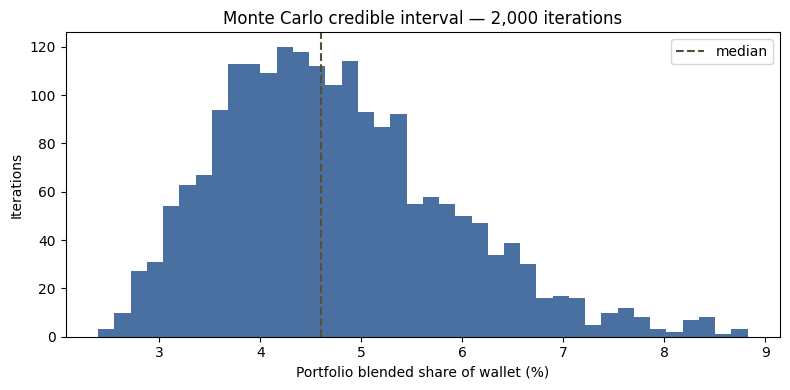

In [6]:
mc = pd.read_parquet(PROCESSED / "monte_carlo_results.parquet")
p5, p50, p95 = mc["portfolio_share"].quantile([0.05, 0.5, 0.95])
print(f"Monte Carlo, {len(mc):,} iterations")
print(f"5th percentile:  {p5:.1%}")
print(f"Median:          {p50:.1%}")
print(f"95th percentile: {p95:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mc["portfolio_share"] * 100, bins=40, color="#4a6fa1", edgecolor="none")
ax.axvline(p50 * 100, color="#574d3b", linestyle="--", label="median")
ax.set_xlabel("Portfolio blended share of wallet (%)")
ax.set_ylabel("Iterations")
ax.set_title("Monte Carlo credible interval — 2,000 iterations")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
tornado = pd.read_parquet(PROCESSED / "tornado_sensitivity.parquet")
tornado.sort_values("share_swing_pp", ascending=False)[
    ["assumption", "share_at_low", "share_at_high", "share_swing_pp"]
].head(5)

,assumption,share_at_low,share_at_high,share_swing_pp
0,transactional_banking.payments_per_zar_throughput,0.067572,0.034581,3.299113
1,transactional_banking.fee_per_payment_zar.SWIFT,0.062965,0.045431,1.753340
2,transactional_banking.avg_balance_days_of_revenue,0.058943,0.043154,1.578862
3,transactional_banking.deposit_nii_margin_bps,0.046677,0.061790,1.511346
4,transactional_banking.fee_per_payment_zar.RTC,0.053608,0.051198,0.241074


## 6. Opportunity Ranking

`expected_value = wallet_gap × win_probability × margin`, per hackathon.txt's
formula — ranked by commercial value, not raw gap size. Dual-listed global
majors (whose Phase 3 revenue is a global, not South-Africa-specific figure)
are reported separately, never mixed into the primary ranking.

In [8]:
ranking = pd.read_parquet(PROCESSED / "opportunity_ranking_entity.parquet")
sa_domestic = ranking[~ranking.is_global_major].sort_values("total_expected_value_zar", ascending=False)

print(f"SA-domestic entities ranked: {len(sa_domestic)}")
print(f"Total ranked expected value: R{sa_domestic.total_expected_value_zar.sum()/1e6:,.1f}m")
print(f"Entities flagged for sequencing risk: {int(sa_domestic.any_sequencing_flag.sum())} / {len(sa_domestic)}")

sa_domestic[["rank", "entity_name", "sector", "total_expected_value_zar", "win_probability", "top_sub_component_label", "any_sequencing_flag"]].head(10)

SA-domestic entities ranked: 12
Total ranked expected value: R1,070.4m
Entities flagged for sequencing risk: 9 / 12


,rank,entity_name,sector,total_expected_value_zar,win_probability,top_sub_component_label,any_sequencing_flag
0,1,Shoprite Holdings,consumer,1.937739e+08,0.541845,Payment fees (transaction volume & pricing),True
1,2,Bid Corporation,consumer,1.684563e+08,0.508043,Payment fees (transaction volume & pricing),True
2,3,MTN Group,telecoms,1.419091e+08,0.536919,Payment fees (transaction volume & pricing),True
3,4,Vodacom Group,telecoms,1.236922e+08,0.517935,Payment fees (transaction volume & pricing),True
4,5,Sanlam,insurance,1.060163e+08,0.532856,Payment fees (transaction volume & pricing),False
5,6,The Bidvest Group,industrials_pharma,1.040424e+08,0.544903,Payment fees (transaction volume & pricing),True
6,7,Valterra Platinum,mining,8.455237e+07,0.488865,Payment fees (transaction volume & pricing),True
7,8,Pepkor Holdings,consumer,4.729092e+07,0.716939,Payment fees (transaction volume & pricing),False
8,9,Clicks Group,consumer,3.608456e+07,0.506901,Payment fees (transaction volume & pricing),True
9,10,Aspen Pharmacare,industrials_pharma,2.946677e+07,0.539127,Payment fees (transaction volume & pricing),False


## 7. Generative AI Component #3 — Client Briefing Notes

Every briefing note is generated strictly from already-computed figures
(Phase 2–6 output) — the prompt never sees raw ledger data, and the system
instruction forbids inventing a number, product, or fact. The brief asks for
at least 3; all 20 clients have one.

In [9]:
briefings = pd.read_parquet(PROCESSED / "briefing_notes.parquet")
top_id = sa_domestic.iloc[0]["entity_id"]
example = briefings[briefings.entity_id == top_id].iloc[0]

print(f"Client: {example['entity_name']}\n")
print(f"Headline: {example['headline']}\n")
print(f"Summary: {example['summary']}\n")
print(f"Recommended next step: {example['recommended_next_step']}")

Client: Shoprite Holdings

Headline: R193.8m expected-value opportunity, driven by Payment fees (transaction volume & pricing) within Transactional Banking

Summary: Shoprite Holdings presents a total expected-value opportunity of R193.8m, with a total wallet gap of R555.5m. The largest opportunity, R128.3m, is anchored in Transactional Banking, specifically within Payment fees (transaction volume & pricing). Our win probability for this opportunity is 54%. Our current relationship strength in Transactional Banking, as measured by share of wallet, is 6%. Additionally, there is R162.0m in unknown capture potential.

Recommended next step: Prioritise deepening the Transactional Banking relationship, specifically focusing on Payment fees (transaction volume & pricing), before pursuing Global Markets or Investment Banking opportunities.


## Reproducibility

- `python run_all.py` reproduces every phase above from raw data end to end.
- `python -m pytest tests/ -q` runs 78 automated tests covering the
  deterministic baselines, null-handling, and ground-truth scoring logic.
- Every LLM call is logged verbatim under `prompts/<namespace>/`, cached
  under `cache/` (gitignored), and timed/costed in
  `reports/llm_usage_log.jsonl`.
- Full narrative write-up, every assumption, and every disclosed limitation:
  `METHODOLOGY.md`.

In [10]:
import subprocess
result = subprocess.run(["python", "-m", "pytest", str(ROOT / "tests"), "-q"], capture_output=True, text=True, cwd=ROOT)
print(result.stdout[-500:])

==== warnings summary ===============================
..\..\..\..\AppData\Roaming\Python\Python314\site-packages\google\genai\types.py:43
  C:\Users\juddj\AppData\Roaming\Python\Python314\site-packages\google\genai\types.py:43: DeprecationWarning: '_UnionGenericAlias' is deprecated and slated for removal in Python 3.17
    VersionedUnionType = Union[builtin_types.UnionType, _UnionGenericAlias]

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
78 passed, 1 warning in 5.44s

